## Вычисляем  регрессию для признака SI, используя  разные наборы  данных из исходного датасета ( включая вариант с PCA ). Для финальной модели буду использовать GradientBoostingRegressor с перебором параметров

In [1]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.feature_selection import SelectKBest, f_classif
from skfeature.function.similarity_based import fisher_score

from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE

from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.feature_selection import RFECV, SelectFromModel, mutual_info_regression
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
#Загружаем предобработанный датасет и  данные отобранные на  шаге исследования (EDA) различными методами
drugs_all = pd.read_csv('drugs_fin_clean.csv') #
select_sum = pd.read_csv('selected_sum.csv')
select_cP_tF = pd.read_csv('select_cP_tF.csv')
selected_features_MutRegr = pd.read_csv('selected_features_MutRegrv2.csv')
select_RF = pd.read_csv('select_RF.csv')
selected_features_Lasso = pd.read_csv('selected_features_Lasso.csv')
selected_features_Forward = pd.read_csv('selected_features_Forward.csv')
selected_features_Backwards = pd.read_csv('selected_features_Backwards.csv')

In [5]:
feature_sets = {
    'MI': selected_features_MutRegr['0'].tolist(),
    'select_sum': select_sum['0'].tolist(),
    'select_cP_tF': select_cP_tF['0'].tolist(),
    'select_RF': select_RF['0'].tolist(),
    'selected_features_Backwards': selected_features_Backwards['0'].tolist(),
    'selected_features_Forward': selected_features_Forward['0'].tolist(),
    'selected_features_Lasso': selected_features_Lasso['0'].tolist(),
}


Train: (775, 210), Test: (194, 210)

=== Сравнение методов отбора ===
                Feature Set  n_features        CV R^2 Test R^2 Test MAE Test RMSE
                         MI          53 0.266 ± 0.068    0.130    1.169     1.628
                 select_sum         134 0.265 ± 0.070    0.142    1.173     1.617
               select_cP_tF         120 0.265 ± 0.072    0.128    1.180     1.631
                  select_RF         100 0.267 ± 0.073    0.144    1.169     1.616
selected_features_Backwards          80 0.263 ± 0.074    0.146    1.165     1.613
  selected_features_Forward          80 0.227 ± 0.066    0.117    1.195     1.641
    selected_features_Lasso          57 0.257 ± 0.067    0.100    1.216     1.656
        PCA (60 components)          60 0.227 ± 0.078    0.124    1.216     1.635

 Финальная модель
Лучший набор признаков: selected_features_Backwards

Финальные метрики на тесте:
  R^2 = 0.1450
  MAE = 1.1700
  RMSE = 1.6147


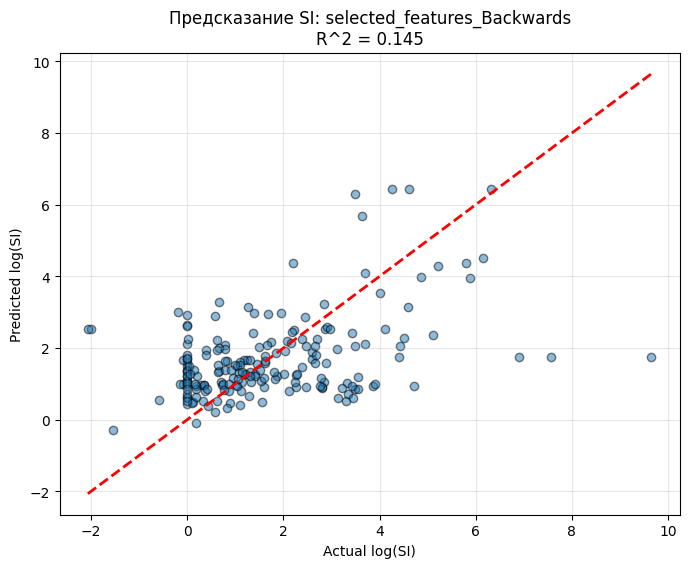

In [ ]:

X = drugs_all.drop(columns=['SI','CC50, mM','IC50, mM']).copy()
y = drugs_all['SI']

feature_names = X.columns.tolist()

# Разделение данных

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Дополнительно: PCA baseline
pca = PCA(n_components=50, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

results = []

X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)

for name, feat_list in feature_sets.items():
    if len(feat_list) == 0:
        continue
    
    # Подмножество признаков
    if isinstance(feat_list, list) and len(feat_list) > 0:
        #idx = [feature_names.index(f) for f in feat_list if f in feature_names]
        # проверить наличие признаков
        existing_features = [f for f in feat_list if f in X_train_df.columns]
        X_train_sub = X_train_df[existing_features].values
        X_test_sub = X_test_df[existing_features].values

    else:
        continue
    
    # Random Forest
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)
    rf_model.fit(X_train_sub, y_train)
    y_pred = rf_model.predict(X_test_sub)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Кросс-валидация
    cv_scores = cross_val_score(rf_model, X_train_sub, y_train, cv=5, scoring='r2')
    
    results.append({
        'Feature Set': name,
        'n_features': len(feat_list),
        'CV R^2': f"{cv_scores.mean():.3f} ± {cv_scores.std():.3f}",
        'Test R^2': f"{r2:.3f}",
        'Test MAE': f"{mae:.3f}",
        'Test RMSE': f"{rmse:.3f}"
    })

# Добавляем PCA
rf_pca = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)
rf_pca.fit(X_train_pca, y_train)
y_pred_pca = rf_pca.predict(X_test_pca)
cv_scores_pca = cross_val_score(rf_pca, X_train_pca, y_train, cv=5, scoring='r2')

results.append({
    'Feature Set': 'PCA (60 components)',
    'n_features': 60,
    'CV R^2': f"{cv_scores_pca.mean():.3f} ± {cv_scores_pca.std():.3f}",
    'Test R^2': f"{r2_score(y_test, y_pred_pca):.3f}",
    'Test MAE': f"{mean_absolute_error(y_test, y_pred_pca):.3f}",
    'Test RMSE': f"{np.sqrt(mean_squared_error(y_test, y_pred_pca)):.3f}"
})

results_df = pd.DataFrame(results)
print("\n=== Сравнение методов отбора ===")
print(results_df.to_string(index=False))


# Финальная модель с лучшим набором признаков

print("\n Финальная модель")

# Выбираем лучший набор (по Test R^2)
best_row = results_df.loc[results_df['Test R^2'].astype(float).idxmax()]
best_set_name = best_row['Feature Set']
print(f"Лучший набор признаков: {best_set_name}")

if best_set_name == 'PCA (60 components)':
    X_train_final = X_train_pca
    X_test_final = X_test_pca
    final_features = [f'PC{i+1}' for i in range(30)]
else:
    best_features = feature_sets[best_set_name]
    feature_index = pd.Index(feature_names)
    idx = feature_index.get_indexer(best_features)
    # Фильтруем -1 (ненайденные признаки)
    idx = idx[idx >= 0]
    
    # Проверяем потери
    found_features = [best_features[i] for i in range(len(best_features)) if idx[i] >= 0]
    missing_features = set(best_features) - set(found_features)
    
    if missing_features:
        print(f"Не найдены признаки: {list(missing_features)[:5]}")
    
    X_train_final = X_train_scaled[:, idx]
    X_test_final = X_test_scaled[:, idx]
    final_features = best_features


# Финальная модель 
final_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    random_state=RANDOM_STATE
)
final_model.fit(X_train_final, y_train)
y_pred_final = final_model.predict(X_test_final)

print(f"\nФинальные метрики на тесте:")
print(f"  R^2 = {r2_score(y_test, y_pred_final):.4f}")
print(f"  MAE = {mean_absolute_error(y_test, y_pred_final):.4f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_final)):.4f}")

# Визуализация предсказаний
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_final, alpha=0.5, edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel(f'Actual log(SI)')
plt.ylabel('Predicted log(SI)')
plt.title(f'Предсказание SI: {best_set_name}\nR^2 = {r2_score(y_test, y_pred_final):.3f}')
plt.grid(True, alpha=0.3)
plt.show()



Неожиданно, самый плохой результат из всех до этого   R^2 = 0.1450

1) Какие могут быть проблемы: скорее всего мне не удалось уловить прямые и косвенные связи  химических соединений, и требуется  предварительный кластерный анализ для выделения групп по хим свойствам, хотя,  при этих же выборках  хорошо предсказания сработали на регрессии  IC50 (R^2 = 0.6), попробую обсчитать чистый датасет  без отбора для  сравнения

2) Попробовать убрать стандартизацию, которая как правило не требуется  для метода GradientBoostingRegressor +  попробую подобрать параметры

P/s вероятность неточного деления данных cc50/ic50  возможно присутствуют какие-то накапливающиеся ошибки и SI  не полностью описывает это соотношение 


In [31]:
#  первым делом попробуем расчет  без стандартизации на лучшем наборе признаков

X_2 = drugs_all[selected_features_Backwards['0']]
y_2 = drugs_all['SI']

In [32]:

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold


X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_2, y_2, test_size=0.2, random_state=RANDOM_STATE
)
print(f"\nTrain: {X_train2.shape}, Test: {X_test2.shape}")

# Базовый пайплайн
gb = GradientBoostingRegressor(random_state=42)

# Сетка гиперпараметров -расчет более часа - долго
param_grid = {
    'n_estimators': [20, 50, 100, 150],
    'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None]
}

# Уменьшенная сетка 
param_grid_reduced = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.03, 0.05, 0.07],
    'max_depth': [4, 5, 7],
    'min_samples_split': [5, 10],
    'subsample': [0.8, 0.9]
}

# Кросс-валидация
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# GridSearch
grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid_reduced,
    cv=cv,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train2, y_train2)
print("=== GridSearchCV Results ===")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV R^2: {grid_search.best_score_:.4f}")
print(f"Test R^2: {grid_search.score(X_test2, y_test2):.4f}")


Train: (775, 80), Test: (194, 80)
Fitting 5 folds for each of 108 candidates, totalling 540 fits
=== GridSearchCV Results ===
Best parameters: {'learning_rate': 0.03, 'max_depth': 7, 'min_samples_split': 10, 'n_estimators': 50, 'subsample': 0.8}
Best CV R^2: 0.2355
Test R^2: 0.2058


In [ ]:
#Попробую перебрать модели  для разных наборов в ручную   / спойлер лучше всего сработала выборка  select_sum на модели SVM


#X = drugs_all[selected_features_Backwards['0']].copy()
#X['CC50, mM'] = drugs_all['CC50, mM']
X3 = drugs_all[select_sum['0']] 
y3 = drugs_all['SI'].values

# Разделение
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y3, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train: {X_train3.shape}, Test: {X_test3.shape}\n")

#Масштабирование (сохраняем для разных моделей)

# Для линейных моделей и SVR нужна стандартизация
scaler_standard = StandardScaler()
X_train_std = scaler_standard.fit_transform(X_train3)
X_test_std = scaler_standard.transform(X_test3)

# Для деревьев масштабирование не нужно
X_train_raw = X_train3.values
X_test_raw = X_test3.values


#Базовое сравнение всех моделей

print("сравнение моделей \n")

models = {
    # Линейные модели
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(random_state=RANDOM_STATE),
    'Lasso': Lasso(random_state=RANDOM_STATE),
    
    # Деревья и ансамбли
    'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostRegressor(random_state=RANDOM_STATE),
    
    # Современные бустинги (для хим. данных больше подходят - информация есть такая )
    'XGBoost': XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    'LightGBM': LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    'CatBoost': CatBoostRegressor(random_state=RANDOM_STATE, verbose=False),
    
    # Другие(для разнообразия)
    'KNN': KNeighborsRegressor(),
    'SVR': SVR()
}

# Кому какое масштабирование нужно
scaler_needed = ['Linear Regression', 'Ridge', 'Lasso', 
                 'KNN', 'SVR']

results = []

for name, model in models.items():
    # Выбираем данные
    if name in scaler_needed:
        X_tr, X_te = X_train_std, X_test_std
    else:
        X_tr, X_te = X_train_raw, X_test_raw
    
    try:
        # Кросс-валидация
        cv_scores = cross_val_score(model, X_tr, y_train3, cv=5, scoring='r2', n_jobs=-1)
        
        # Обучение и тест
        model.fit(X_tr, y_train3)
        y_pred = model.predict(X_te)
        
        r2 = r2_score(y_test3, y_pred)
        mae = mean_absolute_error(y_test3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test3, y_pred))
        
        results.append({
            'Model': name,
            'CV R^2 (mean)': cv_scores.mean(),
            'CV R^2 (std)': cv_scores.std(),
            'Test R^2': r2,
            'Test MAE': mae,
            'Test RMSE': rmse,
        })
        
        print(f"{name:20} | CV R^2 = {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Test R^2 = {r2:.4f}")
        
    except Exception as e:
        print(f"{name:20} | Ошибка: {str(e)[:50]}")
        continue

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test R^2', ascending=False)

print("\n=== Топ-5 моделей по Test R^2 ===")
print(results_df.head(5).to_string(index=False))

Train: (775, 134), Test: (194, 134)

сравнение моделей 

Linear Regression    | CV R^2 = 0.0078 ± 0.0905 | Test R^2 = -0.0382
Ridge                | CV R^2 = 0.0591 ± 0.0766 | Test R^2 = -0.0329
Lasso                | CV R^2 = -0.0045 ± 0.0029 | Test R^2 = -0.0001
Decision Tree        | CV R^2 = -0.2607 ± 0.0568 | Test R^2 = -0.2427
Random Forest        | CV R^2 = 0.2541 ± 0.0732 | Test R^2 = 0.1093
Gradient Boosting    | CV R^2 = 0.2046 ± 0.0608 | Test R^2 = 0.1629
AdaBoost             | CV R^2 = 0.1645 ± 0.0492 | Test R^2 = 0.1040
XGBoost              | CV R^2 = 0.1418 ± 0.1256 | Test R^2 = -0.0150
LightGBM             | CV R^2 = 0.2139 ± 0.0668 | Test R^2 = 0.0147
CatBoost             | CV R^2 = 0.2248 ± 0.0821 | Test R^2 = 0.0814
KNN                  | CV R^2 = 0.1237 ± 0.0356 | Test R^2 = 0.0266
SVR                  | CV R^2 = 0.1867 ± 0.0652 | Test R^2 = 0.2832

=== Топ-5 моделей по Test R^2 ===
            Model  CV R^2 (mean)  CV R^2 (std)  Test R^2  Test MAE  Test RMSE
       